# Cleaning 1

Setup, mapping, and data cleaning for BPS ADM4 × PODES × IUP (desa/kelurahan).

Written by: Atha Bintang Wahyu M.

## Setup

In [6]:
# Base & visualization
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Paths to BPS ADM4 shapefiles (by region ID)
base_dir = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/idn_adm_bps_adm4_20200401_shp"
shp_files = [
    f"{base_dir}/idn_admbnda_adm4_ID1_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID2_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID3_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID5_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID6_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID7_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID8_bps_20200401.shp",
    f"{base_dir}/idn_admbnda_adm4_ID9_bps_20200401.shp",
]
# BPS (ID1=Aceh, ID2=Sumatera Utara, ID3=Sumatera Barat, ID5=Sumatera Selatan, ID6=Bengkulu, ID7=Lampung, ID8=Kep. Bangka Belitung, ID9=Kep. Riau)
region_labels = ["ID1 (Aceh)", "ID2 (Sumatera Utara)", "ID3 (Sumatera Barat)", "ID5 (Sumatera Selatan)", "ID6 (Bengkulu)", "ID7 (Lampung)", "ID8 (Kep. Bangka Belitung)", "ID9 (Kep. Riau)"]
file_adm4_national = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/idn_adm_bps_20200401_shp/idn_admbnda_adm4_bps_20200401.shp"
# Data BIG
file_batas_desa = "/Users/athamawardi/Downloads/batas_desa/batas_desa.shp"

file_podes = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/PODES_ALL/podes_desa_2024.dta"

In [7]:
# Load all ADM4 GeoDataFrames
gdfs = []
for path in shp_files:
    try:
        gdf = gpd.read_file(path)
        gdfs.append(gdf)
        print(f"Loaded {path.split('/')[-1]}: {len(gdf)} features")
    except Exception as e:
        print(f"Error loading {path}: {e}")
        gdfs.append(None)

Loaded idn_admbnda_adm4_ID1_bps_20200401.shp: 25153 features
Loaded idn_admbnda_adm4_ID2_bps_20200401.shp: 418 features
Loaded idn_admbnda_adm4_ID3_bps_20200401.shp: 25376 features
Loaded idn_admbnda_adm4_ID5_bps_20200401.shp: 5183 features
Loaded idn_admbnda_adm4_ID6_bps_20200401.shp: 7228 features
Loaded idn_admbnda_adm4_ID7_bps_20200401.shp: 10648 features
Loaded idn_admbnda_adm4_ID8_bps_20200401.shp: 2473 features
Loaded idn_admbnda_adm4_ID9_bps_20200401.shp: 5432 features


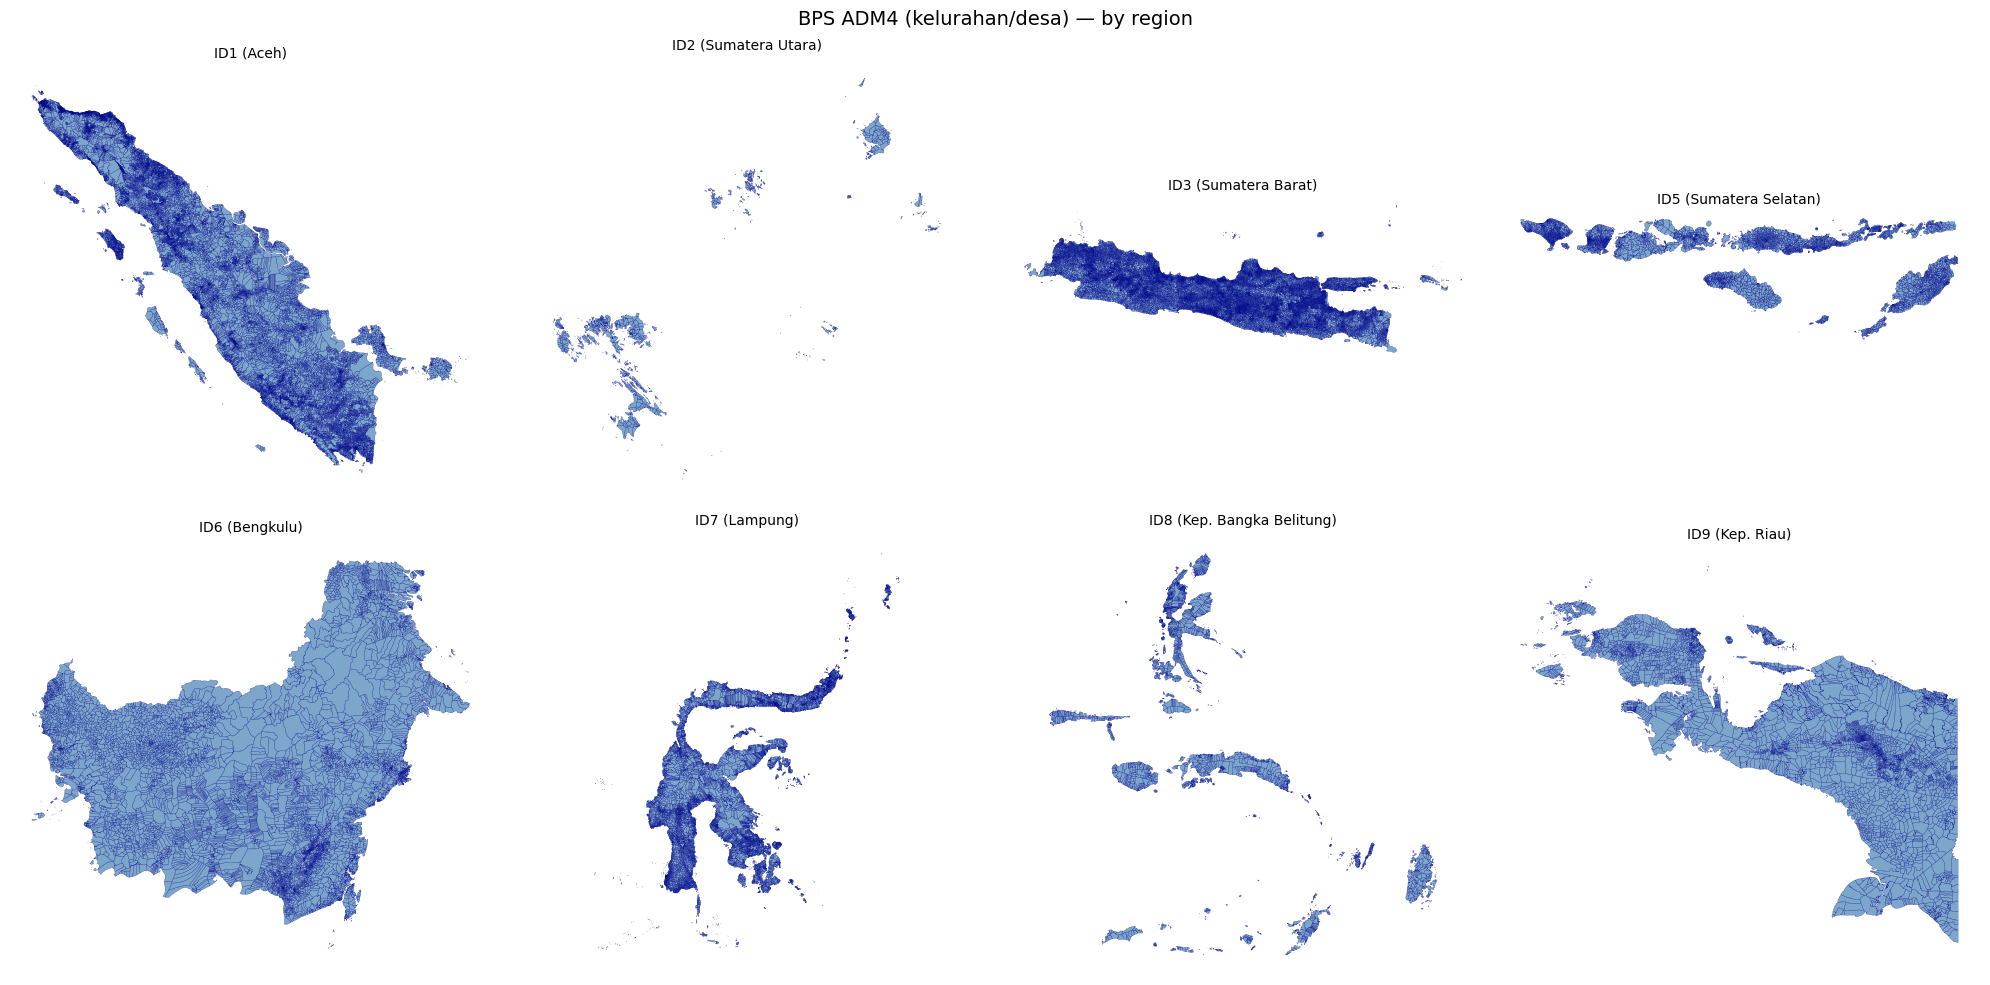

In [3]:
# Single figure: one map per region (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (gdf, label) in enumerate(zip(gdfs, region_labels)):
    ax = axes[i]
    if gdf is not None:
        gdf.plot(ax=ax, facecolor="steelblue", edgecolor="darkblue", linewidth=0.2, alpha=0.7)
        ax.set_title(label, fontsize=10)
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label, fontsize=10)
    ax.axis("off")

plt.suptitle("BPS ADM4 (kelurahan/desa) — by region", fontsize=14)
plt.tight_layout()
plt.show()

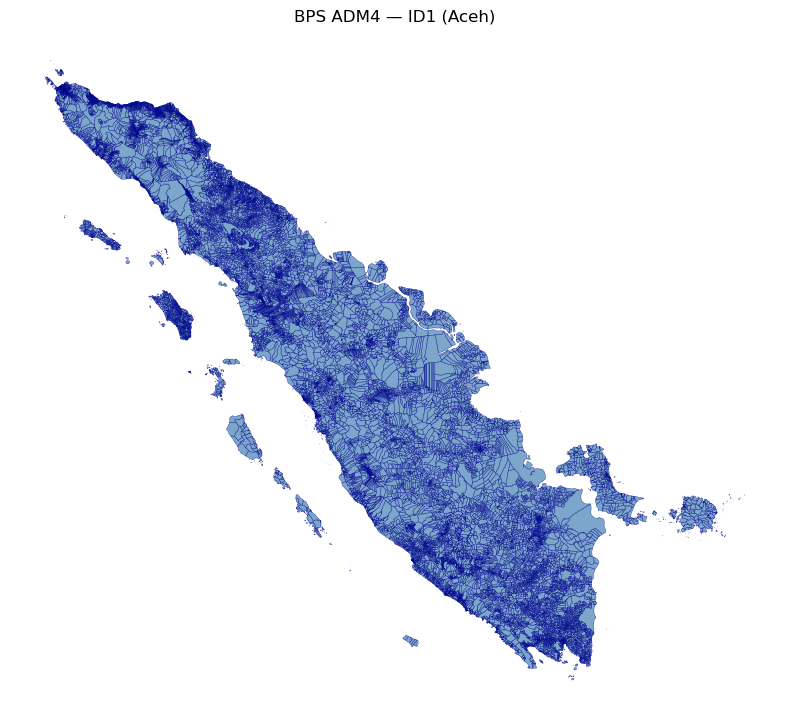

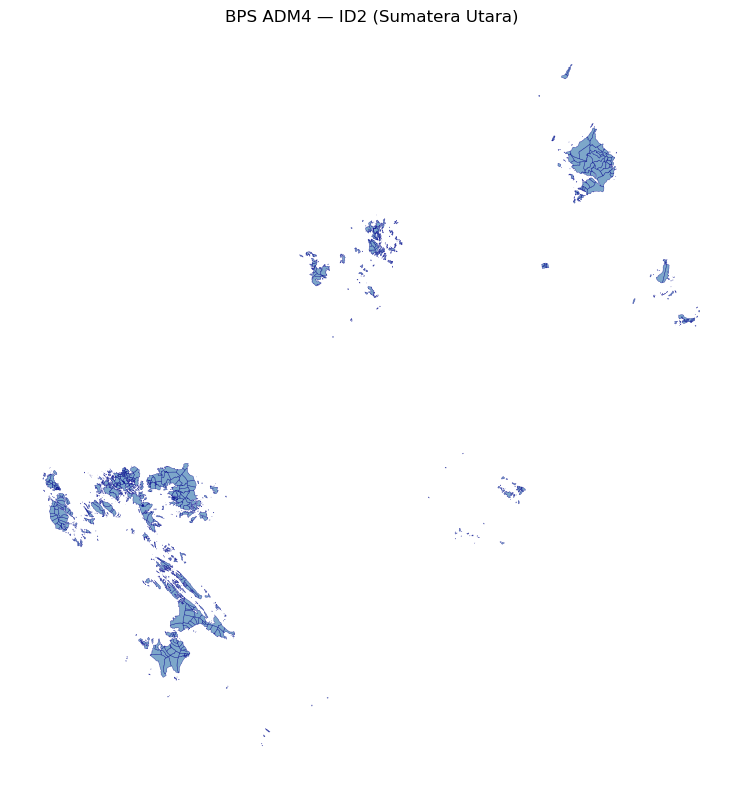

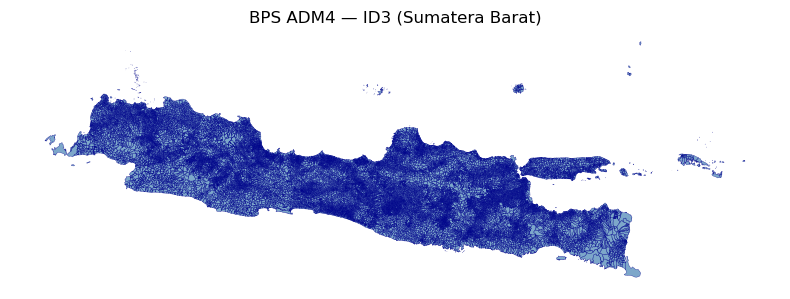

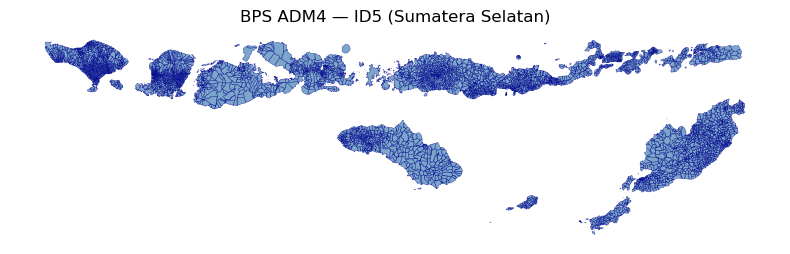

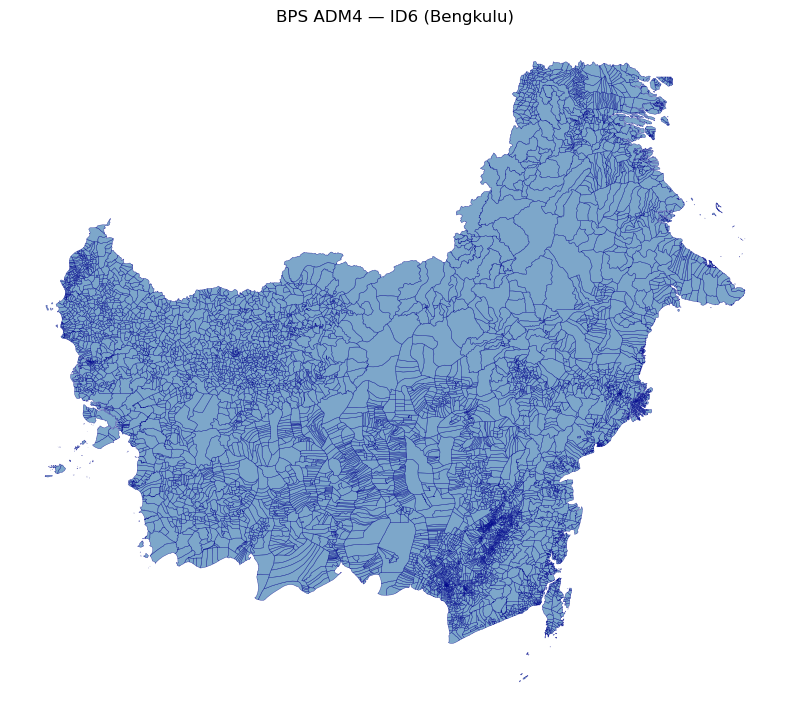

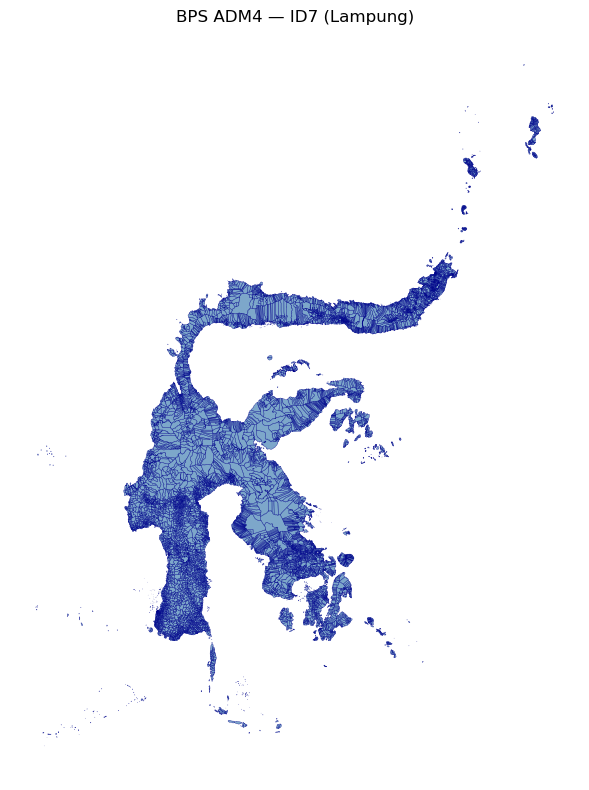

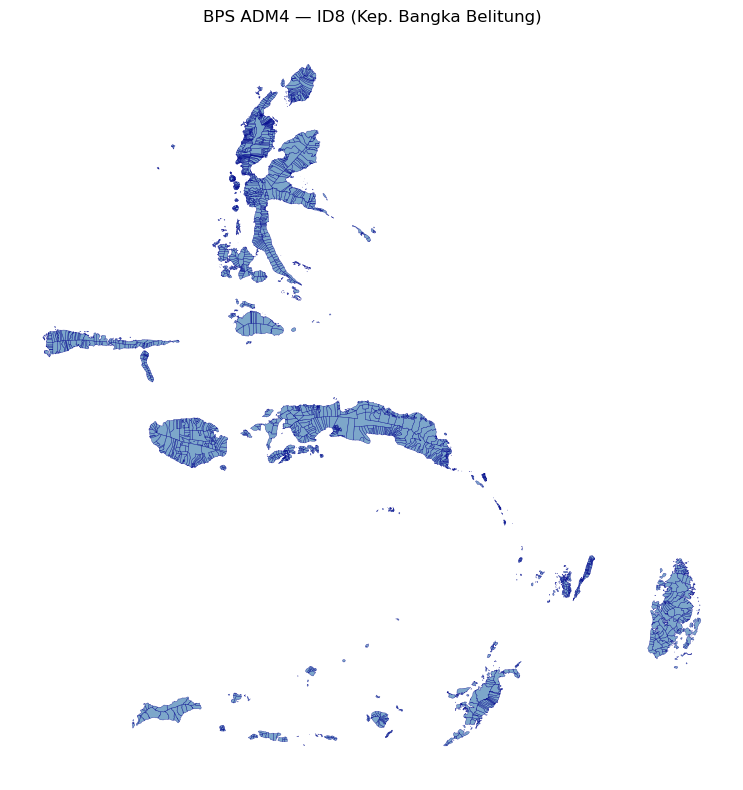

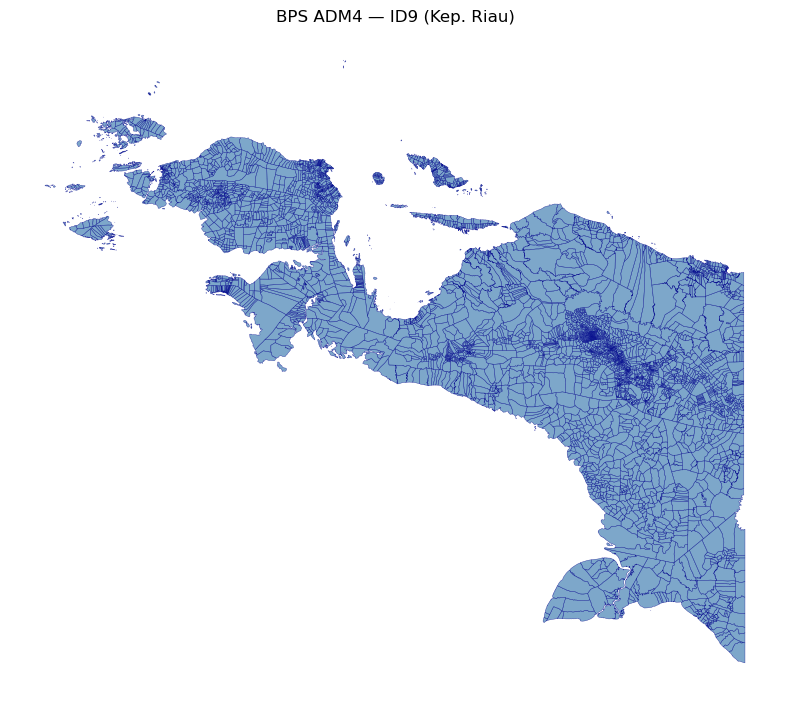

In [4]:
# Individual maps (one figure per region) — optional: run to get larger single-region maps
for i, (gdf, label) in enumerate(zip(gdfs, region_labels)):
    if gdf is None:
        continue
    fig, ax = plt.subplots(figsize=(8, 8))
    gdf.plot(ax=ax, facecolor="steelblue", edgecolor="darkblue", linewidth=0.3, alpha=0.7)
    ax.set_title(f"BPS ADM4 — {label}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

ADM4 national: 81912 features


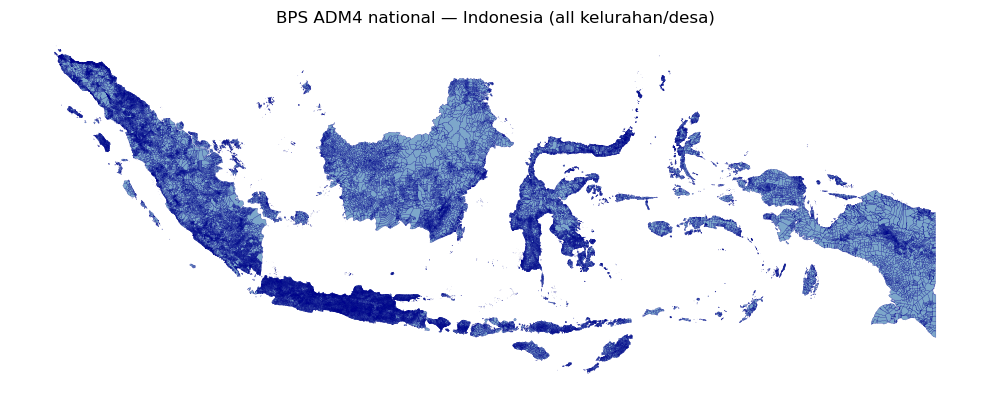

In [5]:
# BPS ADM4 national — all kelurahan/desa in one file
gdf_adm4_national = gpd.read_file(file_adm4_national)
print(f"ADM4 national: {len(gdf_adm4_national)} features")

fig, ax = plt.subplots(figsize=(10, 12))
gdf_adm4_national.plot(ax=ax, facecolor="steelblue", edgecolor="darkblue", linewidth=0.2, alpha=0.7)
ax.set_title("BPS ADM4 national — Indonesia (all kelurahan/desa)")
ax.axis("off")
plt.tight_layout()
plt.show()

Batas desa: 77473 features


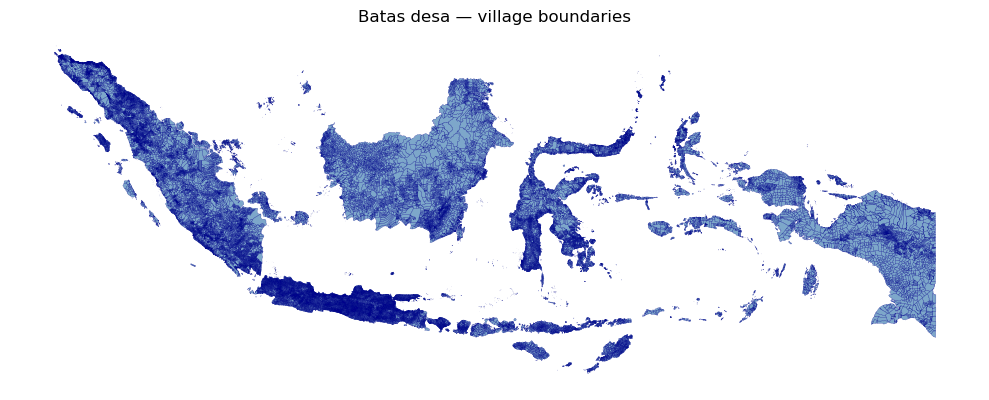

In [6]:
# Batas desa — village boundaries
gdf_batas_desa = gpd.read_file(file_batas_desa)
print(f"Batas desa: {len(gdf_batas_desa)} features")

fig, ax = plt.subplots(figsize=(10, 12))
gdf_batas_desa.plot(ax=ax, facecolor="steelblue", edgecolor="darkblue", linewidth=0.2, alpha=0.7)
ax.set_title("Batas desa — village boundaries")
ax.axis("off")
plt.tight_layout()
plt.show()

## Match ADM4 shapefile with PODES 2024

BPS ADM4 shapefile uses ADM4_PCODE (e.g. `ID1671060006` = "ID" + 10-digit code).  
PODES uses IDDESA (10-digit village code, e.g. `1101010001`). The numeric part of ADM4_PCODE matches IDDESA for the same village.

In [7]:
gdf_adm4 = gpd.read_file(file_adm4_national)
podes = pd.read_stata(file_podes)

def bps_to_id_desa(pcode):
    if pcode is None or (isinstance(pcode, float) and pd.isna(pcode)):
        return None
    s = str(pcode).replace("ID", "").strip()
    return int(s) if s.isdigit() and len(s) == 10 else None

gdf_adm4["id_desa_numeric"] = gdf_adm4["ADM4_PCODE"].apply(bps_to_id_desa)
podes["id_desa_numeric"] = pd.to_numeric(podes["IDDESA"], errors="coerce")
podes_clean = podes.dropna(subset=["id_desa_numeric"])
podes_clean["id_desa_numeric"] = podes_clean["id_desa_numeric"].astype("int64")

adm4_matched = gdf_adm4.merge(
    podes_clean, on="id_desa_numeric", how="left", suffixes=("_shp", "_podes")
)

n = len(adm4_matched)
n_matched = adm4_matched["IDDESA"].notna().sum()
print(f"ADM4 polygons: {n}, matched with PODES: {n_matched} ({100*n_matched/n:.1f}%)")

adm4_matched.to_file("Data/adm4_matched_podes_2024.gpkg", driver="GPKG")

ADM4 polygons: 81912, matched with PODES: 77123 (94.2%)


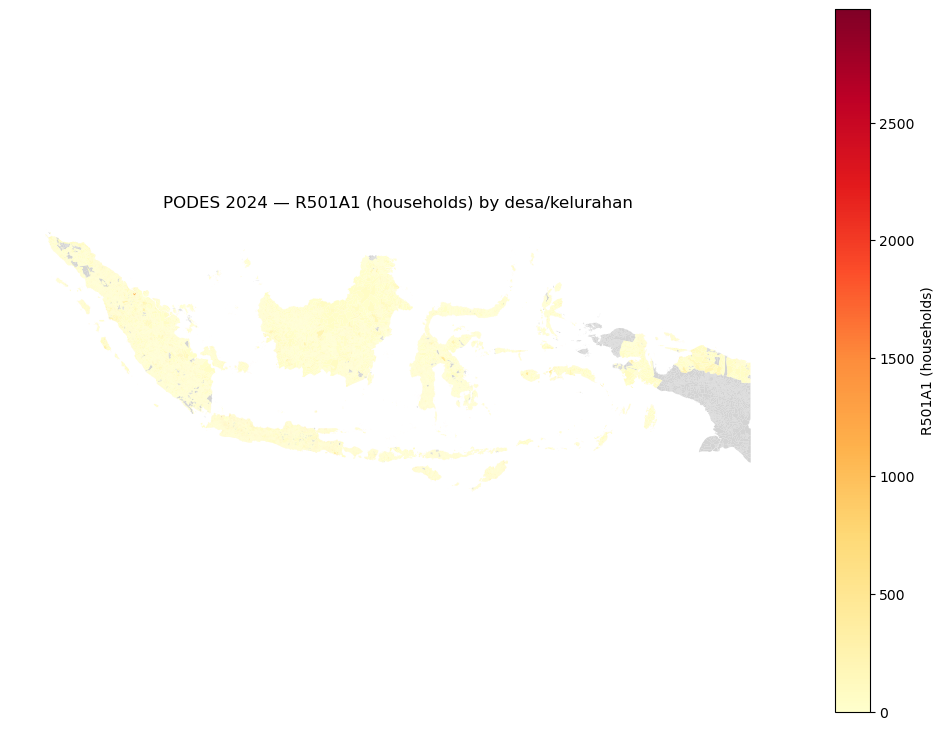

In [8]:
gpkg_path = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/adm4_matched_podes_2024.gpkg"
gdf = gpd.read_file(gpkg_path)

var = "R1501A_K3"
gdf[var] = pd.to_numeric(gdf[var], errors="coerce")

fig, ax = plt.subplots(figsize=(10, 12))
# Plot unmatched (no PODES) in light gray first
mask_na = gdf[var].isna()
gdf[mask_na].plot(ax=ax, color="lightgray", edgecolor="none", label="No PODES match")
# Choropleth for matched villages
gdf[~mask_na].plot(
    column=var,
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={"label": "R501A1 (households)", "shrink": 0.6},
    edgecolor="none",
    linewidth=0,
)
ax.set_title("PODES 2024 — R501A1 (households) by desa/kelurahan")
ax.axis("off")
plt.tight_layout()
plt.show()

In [9]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 81912 entries, 0 to 81911
Columns: 814 entries, Shape_Leng to geometry
dtypes: datetime64[ms](3), float64(735), geometry(1), int64(1), object(74)
memory usage: 508.7+ MB


## Spatial overlay

Alternative merging

In [10]:
# BPS→PODES then IUP overlay
def bps_pcode_to_iddesa(pcode):
    if pcode is None or (isinstance(pcode, float) and pd.isna(pcode)):
        return None
    s = str(pcode).replace("ID", "").strip()
    return int(s) if s.isdigit() and len(s) == 10 else None

file_bps = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/idn_adm_bps_20200401_shp/idn_admbnda_adm4_bps_20200401.shp"
file_podes = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/PODES_ALL/podes_desa_2024.dta"
file_iup = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Desa_dengan_IUP/Desa_dengan_IUP.shp"

gdf_bps = gpd.read_file(file_bps)
podes = pd.read_stata(file_podes)
podes["id_desa_numeric"] = pd.to_numeric(podes["IDDESA"], errors="coerce")
podes_clean = podes.dropna(subset=["id_desa_numeric"]).copy()
podes_clean["id_desa_numeric"] = podes_clean["id_desa_numeric"].astype("int64")

gdf_bps["id_desa_numeric"] = gdf_bps["ADM4_PCODE"].apply(bps_pcode_to_iddesa)
bps_podes = gdf_bps.merge(podes_clean, on="id_desa_numeric", how="inner")
bps_podes = bps_podes[["geometry", "id_desa_numeric"] + [c for c in podes_clean.columns if c != "id_desa_numeric"]]

gdf_iup = gpd.read_file(file_iup).to_crs(bps_podes.crs)
joined = gpd.sjoin(
    gdf_iup[["geometry", "OBJECTID", "KDEPUM", "NAMOBJ", "WADMKC", "idprov", "idkab"]],
    bps_podes[["geometry", "id_desa_numeric"]],
    how="left",
    predicate="intersects",
)
if joined.index.duplicated().any():
    joined = joined[~joined.index.duplicated(keep="first")]
keep_cols = [c for c in ["geometry", "OBJECTID", "KDEPUM", "NAMOBJ", "WADMKC", "idprov", "idkab", "id_desa_numeric"] if c in joined.columns]
r1_matched = joined[keep_cols].merge(podes_clean, on="id_desa_numeric", how="left")
r1_gdf = gpd.GeoDataFrame(r1_matched, geometry="geometry", crs=bps_podes.crs)
n_r1 = r1_gdf["IDDESA"].notna().sum()
print(f"IUP with PODES (spatial overlay): {n_r1} / {len(gdf_iup)} ({100*n_r1/len(gdf_iup):.1f}%)")

# BPS+PODES ∩ IUP 
r2_join = gpd.sjoin(bps_podes, gdf_iup[["geometry"]], how="inner", predicate="intersects")
n_r2 = r2_join.index_right.nunique() if "index_right" in r2_join.columns else len(r2_join)
print(f"Unique IUP covered by BPS+PODES: {n_r2} / {len(gdf_iup)} ({100*n_r2/len(gdf_iup):.1f}%)")

# r1_gdf.to_file("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/iup_podes_best_regime.gpkg", driver="GPKG")

IUP with PODES (spatial overlay): 14198 / 14461 (98.2%)
Unique IUP covered by BPS+PODES: 14198 / 14461 (98.2%)


## Match Desa dengan IUP (villages with IUP) with PODES 2024

Different from the BPS ADM4 match: IUP shapefile uses KDEPUM (e.g. `33.12.01.2004` = prov.kab.kec.desa). We match by: (1) Code: KDEPUM -> IDDESA (prov×10⁸ + kab×10⁶ + kec×10×10³ + desa%1000); (2) Name fallback: prov, kab, kec name (WADMKC), desa name (NAMOBJ) <-> R101, R102, NAMA_KEC, NAMA_DESA.

In [11]:
# iup_temp_dir = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Desa_dengan_IUP/Desa_dengan_IUP.shp"
# podes2024_dir = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/PODES_ALL/podes_desa_2024.dta"

# # --- match_iup_podes: IUP shapefile ↔ PODES (KDEPUM→IDDESA + name fallback)
# def kdepum_to_iddesa(kdepum):
#     """KDEPUM (e.g. 33.12.01.2004) → numeric IDDESA."""
#     if pd.isna(kdepum) or not str(kdepum).strip():
#         return None
#     parts = str(kdepum).strip().split(".")
#     if len(parts) != 4:
#         return None
#     try:
#         prov, kab, kec, desa = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
#         return prov * 100000000 + kab * 1000000 + (kec * 10) * 1000 + (desa % 1000)
#     except (ValueError, IndexError):
#         return None

# def norm(s):
#     return str(s).strip().upper() if pd.notna(s) else ""

# def load_and_match_iup_podes(shapefile_path=iup_temp_dir, podes_path=podes2024_dir):
#     gdf = gpd.read_file(shapefile_path)
#     podes = pd.read_stata(podes_path)
#     id_col = "IDDESA" if "IDDESA" in podes.columns else "ID_DESA"
#     podes_clean = podes.dropna(subset=[id_col]).copy()
#     podes_clean["id_desa_numeric"] = pd.to_numeric(podes_clean[id_col], errors="coerce")
#     podes_clean = podes_clean.dropna(subset=["id_desa_numeric"]).astype({"id_desa_numeric": "int64"})
#     gdf = gdf.copy()
#     gdf["id_desa_numeric"] = gdf["KDEPUM"].apply(kdepum_to_iddesa)
#     merged = gdf.merge(podes_clean, on="id_desa_numeric", how="left", suffixes=("_shp", "_podes"))
#     n_code = merged[id_col].notna().sum()
#     unmatched = merged[id_col].isna()
#     if unmatched.any():
#         gdf_u = merged.loc[unmatched].copy()
#         for col, pcol in [("_prov", "idprov"), ("_kab", "idkab"), ("_kec_n", "WADMKC"), ("_desa_n", "NAMOBJ")]:
#             gdf_u[col] = gdf_u[pcol].apply(norm)
#         podes["_prov"] = podes["R101"].apply(norm)
#         podes["_kab"] = podes["R102"].apply(norm)
#         podes["_kec_n"] = podes["NAMA_KEC"].apply(norm)
#         podes["_desa_n"] = podes["NAMA_DESA"].apply(norm)
#         name_merged = gdf_u.merge(podes, on=["_prov", "_kab", "_kec_n", "_desa_n"], how="left", suffixes=("", "_y"))
#         name_merged.index = gdf_u.index
#         for c in podes.columns:
#             if c in ("_prov", "_kab", "_kec_n", "_desa_n"): continue
#             src = f"{c}_y" if f"{c}_y" in name_merged.columns else c
#             if src in name_merged.columns and c in merged.columns:
#                 merged.loc[name_merged.index, c] = name_merged[src]
#     n_total = merged[id_col].notna().sum()
#     print(f"IUP polygons: {len(merged)}, matched by code: {n_code}, total: {n_total} ({100*n_total/len(merged):.1f}%)")
#     return merged

# iup_matched = load_and_match_iup_podes()
# iup_matched.to_file("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/iup_matched_podes_2024.gpkg", driver="GPKG")

In [12]:
# gpkg_iup = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/iup_matched_podes_2024.gpkg"
# iup_matched = gpd.read_file(gpkg_iup)
# n = len(iup_matched)
# n_matched = iup_matched["IDDESA"].notna().sum()
# print(f"Desa dengan IUP: {n} polygons, matched with PODES 2024: {n_matched} ({100*n_matched/n:.1f}%)")

In [13]:
# var = "R1501A_K3"
# iup_matched[var] = pd.to_numeric(iup_matched[var], errors="coerce")

# fig, ax = plt.subplots(figsize=(10, 12))
# mask_na = iup_matched[var].isna()
# iup_matched[mask_na].plot(ax=ax, color="lightgray", edgecolor="none", label="No PODES match")
# iup_matched[~mask_na].plot(
#     column=var,
#     ax=ax,
#     legend=True,
#     cmap="YlOrRd",
#     legend_kwds={"label": "R501A1 (households)", "shrink": 0.6},
#     edgecolor="none",
#     linewidth=0,
# )
# ax.set_title("PODES 2024 — R501A1 (households) by desa/kelurahan")
# ax.axis("off")
# plt.tight_layout()
# plt.show()

# Cleaning

Matching and cleaning (no .py): **match_iup_podes** (IUP↔PODES: KDEPUM→IDDESA + name fallback) and **run_r1** (BPS→PODES then IUP overlay; full BPS+PODES+has_iup+aggregates+coverage; consolidated folder). Data bersih per desa.

In [8]:
from fix_podes_2011_id import load_podes_with_2011_fix  
from pathlib import Path
import shutil
BASE = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity")
BPS_ADM4_PATH = BASE / "Data/idn_adm_bps_20200401_shp/idn_admbnda_adm4_bps_20200401.shp"
PODES_DIR = BASE / "Data/PODES_ALL"
IUP_PATH = BASE / "Data/Desa_dengan_IUP/Desa_dengan_IUP.shp"
DATA_BERSIH = BASE / "Data" / "DATA_BERSIH"  
AREA_CRS = "EPSG:32748"

In [9]:
# --- BPS -> PODES lalu IUP overlay (metode yang sama seperti sebelum)
def bps_pcode_to_iddesa(pcode):
    s = str(pcode).replace("ID", "").strip() if pcode is not None and not (isinstance(pcode, float) and pd.isna(pcode)) else ""
    return int(s) if s.isdigit() and len(s) == 10 else None

def load_podes(podes_path):
    podes = pd.read_stata(podes_path)
    id_col = "IDDESA" if "IDDESA" in podes.columns else "ID_DESA"
    podes["id_desa_numeric"] = pd.to_numeric(podes[id_col], errors="coerce")
    podes_clean = podes.dropna(subset=["id_desa_numeric"]).copy()
    podes_clean["id_desa_numeric"] = podes_clean["id_desa_numeric"].astype("int64")
    return podes_clean

def run_r1_save_iup_podes(bps_gdf, podes_clean, iup_gdf, out_path):
    bps_gdf = bps_gdf.copy()
    bps_gdf["id_desa_numeric"] = bps_gdf["ADM4_PCODE"].apply(bps_pcode_to_iddesa)
    bps_podes = bps_gdf.merge(podes_clean, on="id_desa_numeric", how="inner", suffixes=("_shp", "_podes"))
    bps_podes = bps_podes[["geometry", "id_desa_numeric"] + [c for c in podes_clean.columns if c != "id_desa_numeric"]]
    iup_crs = iup_gdf.to_crs(bps_podes.crs)
    joined = gpd.sjoin(iup_crs, bps_podes[["geometry", "id_desa_numeric"]], how="left", predicate="intersects")
    if joined.index.duplicated().any():
        joined = joined[~joined.index.duplicated(keep="first")]
    merged = joined.merge(podes_clean, on="id_desa_numeric", how="left", suffixes=("", "_podes"))
    if "geometry_right" in merged.columns:
        merged = merged.drop(columns=["geometry_right"])
    out_gdf = gpd.GeoDataFrame(merged, geometry="geometry", crs=bps_podes.crs)
    out_gdf.to_file(out_path, driver="GPKG")
    match_col = "IDDESA" if "IDDESA" in out_gdf.columns else "ID_DESA"
    return out_gdf[match_col].notna().sum(), len(iup_gdf)

In [10]:
# --- IUP aggregates + coverage per desa; full BPS+PODES+has_iup
def add_iup_aggregates_and_coverage(full_gdf, r1_iup_gdf):
    full = full_gdf.copy()
    r1 = r1_iup_gdf.copy()
    r1["id_desa_numeric"] = pd.to_numeric(r1["id_desa_numeric"], errors="coerce")
    r1 = r1.dropna(subset=["id_desa_numeric"])
    r1["id_desa_numeric"] = r1["id_desa_numeric"].astype("int64")
    agg = r1.groupby("id_desa_numeric").agg(n_wiup=("id_desa_numeric", "count"), n_nmoprt=("nmoprt", "nunique")).reset_index()
    for col, prefix in [("issuer", "n_issuer"), ("tipopr", "n_tipopr"), ("status", "n_status"), ("clascmd", "n_clascmd")]:
        if col not in r1.columns: continue
        r1[col] = r1[col].astype(str).str.strip()
        counts = r1.groupby("id_desa_numeric")[col].value_counts().unstack(fill_value=0).add_prefix(f"{prefix}_").reset_index()
        agg = agg.merge(counts, on="id_desa_numeric", how="left")
    if "datstr" in r1.columns:
        r1["year_start"] = pd.to_datetime(r1["datstr"], errors="coerce").dt.year
        agg = agg.merge(r1.groupby("id_desa_numeric")["year_start"].agg(["min", "max"]).reset_index().rename(columns={"min": "iup_year_min", "max": "iup_year_max"}), on="id_desa_numeric", how="left")
    if "datend" in r1.columns:
        r1["year_end"] = pd.to_datetime(r1["datend"], errors="coerce").dt.year
        agg = agg.merge(r1.groupby("id_desa_numeric")["year_end"].agg(["min", "max"]).reset_index().rename(columns={"min": "iup_datend_year_min", "max": "iup_datend_year_max"}), on="id_desa_numeric", how="left")
    full_proj = full.to_crs(AREA_CRS)
    r1_proj = r1_iup_gdf.to_crs(AREA_CRS)
    r1_proj["id_desa_numeric"] = pd.to_numeric(r1_proj["id_desa_numeric"], errors="coerce")
    r1_proj = r1_proj.dropna(subset=["id_desa_numeric"])
    r1_proj["id_desa_numeric"] = r1_proj["id_desa_numeric"].astype("int64")
    full_ids = set(full_proj["id_desa_numeric"].dropna().astype("int64"))
    ids_with_iup = set(r1_proj["id_desa_numeric"].unique()) & full_ids
    overlap_by_village = []
    for vid in ids_with_iup:
        bps_row = full_proj.loc[full_proj["id_desa_numeric"] == vid]
        if bps_row.empty: continue
        bps_geom = bps_row.geometry.iloc[0]
        overlap_area = 0.0
        for _, g in r1_proj.loc[r1_proj["id_desa_numeric"] == vid, "geometry"].items():
            inter = bps_geom.intersection(g)
            if not inter.is_empty: overlap_area += inter.area
        village_area = bps_geom.area
        overlap_by_village.append({"id_desa_numeric": vid, "area_hectares_iup": overlap_area / 10_000, "pct_iup_coverage": (overlap_area / village_area * 100) if village_area > 0 else 0.0})
    cov_df = pd.DataFrame(overlap_by_village)
    if not cov_df.empty: agg = agg.merge(cov_df, on="id_desa_numeric", how="left")
    else: agg["area_hectares_iup"], agg["pct_iup_coverage"] = 0.0, 0.0
    merge_cols = [c for c in agg.columns if c != "id_desa_numeric"]
    full = full.merge(agg, on="id_desa_numeric", how="left")
    for c in merge_cols:
        if c not in full.columns: continue
        if c in ("pct_iup_coverage", "area_hectares_iup"): full[c] = full[c].fillna(0.0)
        elif c.startswith("n_"): full[c] = full[c].fillna(0); full[c] = full[c].astype("int64") if full[c].dtype in ("float64", "float32") else full[c]
    return full

def build_full_adm4_podes_with_iup_flag(bps_gdf, podes_clean, iup_gdf, out_path, r1_iup_podes_path=None, save_csv=False):
    bps_gdf = bps_gdf.copy()
    bps_gdf["id_desa_numeric"] = bps_gdf["ADM4_PCODE"].apply(bps_pcode_to_iddesa)
    full = bps_gdf.merge(podes_clean, on="id_desa_numeric", how="left", suffixes=("_shp", "_podes"))
    if r1_iup_podes_path is not None and r1_iup_podes_path.exists():
        r1_gdf = gpd.read_file(r1_iup_podes_path)
        full["has_iup"] = full["id_desa_numeric"].isin(r1_gdf["id_desa_numeric"].dropna().astype("int64").unique()).astype(int)
        full = add_iup_aggregates_and_coverage(full, r1_gdf)
    else:
        joined = gpd.sjoin(full[["geometry"]], iup_gdf.to_crs(full.crs)[["geometry"]], how="left", predicate="intersects")
        full["has_iup"] = (joined["index_right"].notna().groupby(level=0).any().reindex(full.index, fill_value=False)).astype(int) if "index_right" in joined.columns else 0
        full["n_wiup"], full["pct_iup_coverage"], full["area_hectares_iup"] = 0, 0.0, 0.0
    full.to_file(out_path, driver="GPKG")
    if save_csv:
        full.drop(columns=["geometry"], errors="ignore").to_csv(Path(out_path).with_suffix(".csv"), index=False)
    return int(full["has_iup"].sum()), len(full)


In [11]:
# --- all outputs → Data/DATA_BERSIH
bps_gdf = gpd.read_file(BPS_ADM4_PATH)
iup_gdf = gpd.read_file(IUP_PATH)
podes_files = sorted(PODES_DIR.glob("podes_desa_*.dta"))
DATA_BERSIH.mkdir(parents=True, exist_ok=True)
SAVE_CSV = True  # also export CSV (no geometry)
print(f"Data bersih → {DATA_BERSIH}")
print("R1: IUP + PODES per year → DATA_BERSIH/iup_podes_<year>.gpkg")
for p in podes_files:
    year = p.stem.replace("podes_desa_", "")
    out_path = DATA_BERSIH / f"iup_podes_{year}.gpkg"
    podes_clean = load_podes_with_2011_fix(p)
    n_matched, n_iup = run_r1_save_iup_podes(bps_gdf, podes_clean, iup_gdf, out_path)
    print(f"  {year}: matched {n_matched}/{n_iup} → {out_path.name}")
print("\nFull 2024 → DATA_BERSIH/adm4_podes2024_with_iup_flag.gpkg")
podes_2024 = load_podes_with_2011_fix(PODES_DIR / "podes_desa_2024.dta")
n_iup_villages, n_total = build_full_adm4_podes_with_iup_flag(bps_gdf, podes_2024, iup_gdf, DATA_BERSIH / "adm4_podes2024_with_iup_flag.gpkg", r1_iup_podes_path=DATA_BERSIH / "iup_podes_2024.gpkg", save_csv=SAVE_CSV)
print(f"  has_iup=1: {n_iup_villages}, rows: {n_total}")
print("\nFull per year → DATA_BERSIH/adm4_podes_<year>_with_iup_flag.gpkg")
for p in podes_files:
    year = p.stem.replace("podes_desa_", "")
    r1_path = DATA_BERSIH / f"iup_podes_{year}.gpkg"
    if not r1_path.exists(): continue
    out_full_year = DATA_BERSIH / f"adm4_podes_{year}_with_iup_flag.gpkg"
    podes_clean = load_podes_with_2011_fix(p)
    n_iup_villages, n_rows = build_full_adm4_podes_with_iup_flag(bps_gdf, podes_clean, iup_gdf, out_full_year, r1_iup_podes_path=r1_path, save_csv=SAVE_CSV)
    print(f"  {year}: has_iup=1 {n_iup_villages} → {out_full_year.name}")


Data bersih → /Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/DATA_BERSIH
R1: IUP + PODES per year → DATA_BERSIH/iup_podes_<year>.gpkg
  2011: matched 2987/14461 → iup_podes_2011.gpkg
  2014: matched 14251/14461 → iup_podes_2014.gpkg
  2018: matched 14393/14461 → iup_podes_2018.gpkg


/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/fix_podes_2011_id.py:32: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  podes = pd.read_stata(podes_path)


  2021: matched 14334/14461 → iup_podes_2021.gpkg
  2024: matched 14198/14461 → iup_podes_2024.gpkg

Full 2024 → DATA_BERSIH/adm4_podes2024_with_iup_flag.gpkg
  has_iup=1: 4813, rows: 81912

Full per year → DATA_BERSIH/adm4_podes_<year>_with_iup_flag.gpkg
  2011: has_iup=1 880 → adm4_podes_2011_with_iup_flag.gpkg
  2014: has_iup=1 4846 → adm4_podes_2014_with_iup_flag.gpkg
  2018: has_iup=1 4902 → adm4_podes_2018_with_iup_flag.gpkg


/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/fix_podes_2011_id.py:32: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  podes = pd.read_stata(podes_path)


  2021: has_iup=1 4830 → adm4_podes_2021_with_iup_flag.gpkg
  2024: has_iup=1 4813 → adm4_podes_2024_with_iup_flag.gpkg


In [12]:
# Load cleaned year / panel (satu desa satu baris; data bersih per tahun)
def load_cleaned_year(year):
    p = DATA_BERSIH / f"adm4_podes_{year}_with_iup_flag.gpkg"
    if not p.exists(): return None
    g = gpd.read_file(p)
    g = g.drop_duplicates(subset=["id_desa_numeric"], keep="first")
    g["id_desa_numeric"] = pd.to_numeric(g["id_desa_numeric"], errors="coerce").astype("Int64")
    for c in ["n_wiup", "pct_iup_coverage", "area_hectares_iup"]:
        if c in g.columns: g[c] = g[c].fillna(0)
    for c in g.columns:
        if c.startswith("n_") and g[c].dtype in ("float64", "float32"): g[c] = g[c].fillna(0).astype("int64")
    g = g[g.geometry.is_valid].copy()
    g["year"] = year
    return g

years = [2011, 2014, 2018, 2021, 2024]
panel = pd.concat([g for y in years if (g := load_cleaned_year(y)) is not None], ignore_index=True)
print(f"Panel: {len(panel)} rows, years {panel['year'].min()}-{panel['year'].max()}")

PANEL_GPKG = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/panel_podes_2011-2024.gpkg")
PANEL_CSV = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/panel_podes_2011-2024.csv")
keep_cols = ["id_desa_numeric", "year", "geometry", "has_iup", "n_wiup", "area_hectares_iup", "pct_iup_coverage"]
admin_cols = [c for c in ["NAMA_PROV", "NAMA_KAB", "NAMA_KEC", "NAMA_DESA", "ADM1_EN", "ADM2_EN", "ADM3_EN", "ADM4_EN"] if c in panel.columns]
keep_cols = [c for c in keep_cols + admin_cols if c in panel.columns]
panel_mini = panel[keep_cols].copy()
panel_mini["id_desa_numeric"] = panel_mini["id_desa_numeric"].astype("int64")  # GPKG-safe (no Int64)
panel_mini.to_file(PANEL_GPKG, driver="GPKG")
print(f"Saved minimal GPKG: {PANEL_GPKG} ({len(keep_cols)} cols)")
panel.drop(columns=["geometry"], errors="ignore").to_csv(PANEL_CSV, index=False)
print(f"Saved full panel CSV: {PANEL_CSV} ({len(panel.columns)} cols)")

Panel: 409440 rows, years 2011-2024
Saved minimal GPKG: /Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/panel_podes_2011-2024.gpkg (15 cols)


KeyboardInterrupt: 

In [ ]:
# Load cleaned year / panel (satu desa satu baris; data bersih per tahun)
def load_cleaned_year(year):
    p = DATA_BERSIH / f"adm4_podes_{year}_with_iup_flag.gpkg"
    if not p.exists(): return None
    g = gpd.read_file(p)
    g = g.drop_duplicates(subset=["id_desa_numeric"], keep="first")
    g["id_desa_numeric"] = pd.to_numeric(g["id_desa_numeric"], errors="coerce").astype("Int64")
    for c in ["n_wiup", "pct_iup_coverage", "area_hectares_iup"]:
        if c in g.columns: g[c] = g[c].fillna(0)
    for c in g.columns:
        if c.startswith("n_") and g[c].dtype in ("float64", "float32"): g[c] = g[c].fillna(0).astype("int64")
    g = g[g.geometry.is_valid].copy()
    g["year"] = year
    return g

years = [2011, 2014, 2018, 2024]
panel = pd.concat([g for y in years if (g := load_cleaned_year(y)) is not None], ignore_index=True)
print(f"Panel: {len(panel)} rows, years {panel['year'].min()}-{panel['year'].max()}")
panel.to_file("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/panel_podes_2011-2024_2.gpkg", driver="GPKG")

NameError: name 'pd' is not defined